# Property Location and Rental Price Analysis
### Statistical Analysis and Law of Large Numbers

**Course:** Probability and Statistics  
**Project Topic:** Property Location and Rental Price Analysis  
**Group Seminar Topic:** Law of Large Numbers in Real-Life Decision Making  

## Introduction

Rental prices vary quite a bit across different properties and cities. If we look at individual listings, it is hard to get a clear picture of what rent is typically like or how much it varies. This is where basic statistical analysis helps.

In this project, we use a real rental property dataset from Kaggle to study how rental prices are distributed across different cities and how property size relates to rent. We also connect this to our group seminar topic by demonstrating the Law of Large Numbers: as we take random samples of increasing size, the sample mean tends to settle closer to the mean of the full dataset.

## Problem Statement

Rental prices vary across properties and locations. Looking at one or two listings gives no real sense of the typical price or the spread of prices in the market. The project uses statistical analysis on real data to understand this variation and to show how the Law of Large Numbers applies to rental price data.

## Objectives

1. Understand the distribution of rental prices in the dataset.
2. Calculate all required statistical measures: Mean, Median, Mode, Variance, Standard Deviation, IQR, Range, Covariance, and Correlation.
3. Compare rental prices across different cities.
4. Study the relationship between property size and rent.
5. Calculate covariance and correlation between Size and Rent.
6. Demonstrate the Law of Large Numbers using random samples of increasing size.

## Dataset

We are using the **House Rent Prediction Dataset** from Kaggle, uploaded by iamsouravbanerjee.  
Source: https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset

Each row represents one rental property listing. The main columns we use are:

- **Rent** - monthly rental price (main variable)
- **City** - city where the property is located (main location variable)
- **Size** - area of the property in square feet
- **BHK** - number of bedrooms, hall, and kitchen
- **Bathroom** - number of bathrooms
- **Furnishing Status** - whether the property is furnished, semi-furnished, or unfurnished

Not every column is used. We only use the ones that contribute to the analysis.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [183]:
df = pd.read_csv("data/House_Rent_Dataset.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (4746, 12)
Columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']


In [184]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [186]:
print("Missing values per col:")
print(df.isnull().sum())

Missing values per col:
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


In [187]:
print("duplicate rows are", df.duplicated().sum())

duplicate rows are 0


In [188]:
print("cities in ds:")
print(df["City"].value_counts())

cities in ds:
City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64


In [189]:
print("Rent range : rs.", df["Rent"].min(), "to rs.", df["Rent"].max())
print("Size range :", df["Size"].min(), "to", df["Size"].max(), "sq.ft")

Rent range : rs. 1200 to rs. 3500000
Size range : 10 to 8000 sq.ft


## Data cleaning

our dataset has no missing values and no duplicate rows, sab changa geee

In [190]:
print("Rent <= 0:", (df["Rent"] <= 0).sum())
print("Size <= 0:", (df["Size"] <= 0).sum())

Rent <= 0: 0
Size <= 0: 0


In [191]:
# Check very small property sizes
print(df[df["Size"] < 50][["BHK", "Rent", "Size", "City"]])

      BHK   Rent  Size       City
116     1   5000    20    Kolkata
189     1   6500    44    Kolkata
2445    2  12000    48      Delhi
2449    1  12000    48      Delhi
2460    1   5000    25      Delhi
2491    1   7500    45      Delhi
2627    2   6000    45      Delhi
2631    1  10000    30      Delhi
2870    1  13000    40      Delhi
2885    1  10000    42      Delhi
2913    1   3500    25      Delhi
2935    1   5500    30      Delhi
2973    1   6000    25      Delhi
3922    3  23000    25  Hyderabad
4653    3  15000    10  Hyderabad
4721    1   5500    40  Hyderabad


## Exploratory DA

In [192]:
df[["Rent", "Size", "BHK", "Bathroom"]].describe().round(2)

,Rent,Size,BHK,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,34993.45,967.49,2.08,1.97
std,78106.41,634.20,0.83,0.88
min,1200.00,10.00,1.00,1.00
25%,10000.00,550.00,2.00,1.00
50%,16000.00,850.00,2.00,2.00
75%,33000.00,1200.00,3.00,2.00
max,3500000.00,8000.00,6.00,10.00


In [193]:
print(df["Furnishing Status"].value_counts())

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64


### Rent distribution

how rental prices are distributed across the dataset.

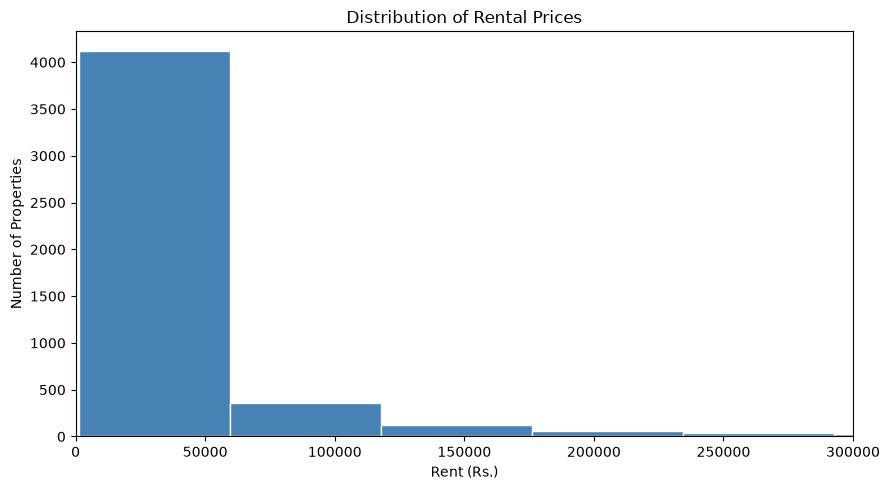

In [194]:
plt.figure(figsize=(9, 5))
plt.hist(df["Rent"], bins=60, color="steelblue", edgecolor="white")
plt.title("Distribution of Rental Prices")
plt.xlabel("Rent (Rs.)")
plt.ylabel("Number of Properties")
plt.xlim(0, 300000)
plt.tight_layout()
plt.show()

The histogram is heavily right skewed 
Most properties have relatively low rents but there are some very high rent listings. 
This kind of skew means the mean will be pulled upward more than the median

## Statistical analysis


In [195]:
rent = df["Rent"]

mean_rent = rent.mean()
print("Mean Rent: Rs.", round(mean_rent, 2))

Mean Rent: Rs. 34993.45


In [196]:
median_rent = rent.median()
print("Median Rent: Rs.", median_rent)

Median Rent: Rs. 16000.0


In [197]:
mode_rent = rent.mode()
print("Mode of Rent:", mode_rent.tolist())

Mode of Rent: [15000]


The mean rent is Rs. 34,993, while the median is Rs. 16,000. There is a noticeable gap between them. This is because of the right-skewed distribution: a small number of very expensive listings pull the mean upward, while the median stays closer to what a typical listing actually costs.

The mode is Rs. 15,000, which is the single most common rental price in the dataset.

In [198]:

var_rent = rent.var()
print("Variance of Rent:", round(var_rent, 2))

Variance of Rent: 6100611741.94


In [199]:
std_rent = rent.std()
print("Standard Deviation of Rent: Rs.", round(std_rent, 2))

Standard Deviation of Rent: Rs. 78106.41


In [200]:
Q1 = rent.quantile(0.25)
Q3 = rent.quantile(0.75)
IQR = Q3 - Q1

print("Q1 (25th percentile): Rs.", Q1)
print("Q3 (75th percentile): Rs.", Q3)
print("IQR: Rs.", IQR)

Q1 (25th percentile): Rs. 10000.0
Q3 (75th percentile): Rs. 33000.0
IQR: Rs. 23000.0


In [201]:
min_rent = rent.min()
max_rent = rent.max()
range_rent = max_rent - min_rent

print("Minimum Rent: Rs.", min_rent)
print("Maximum Rent: Rs.", max_rent)
print("Range: Rs.", range_rent)

Minimum Rent: Rs. 1200
Maximum Rent: Rs. 3500000
Range: Rs. 3498800


The standard deviation (Rs. 78,106) is much larger than the mean (Rs. 34,993). This shows that rental prices vary a lot across properties. The IQR is Rs. 23,000, meaning the middle 50% of properties have rent between Rs. 10,000 and Rs. 33,000. The range is enormous (Rs. 34,98,800), largely because of a few extreme high-rent listings.

In [202]:
# Outlier check using IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(rent < lower_bound) | (rent > upper_bound)]
print("IQR lower bound: Rs.", lower_bound)
print("IQR upper bound: Rs.", upper_bound)
print("Properties outside this range:", len(outliers))

IQR lower bound: Rs. -24500.0
IQR upper bound: Rs. 67500.0
Properties outside this range: 520


520 properties fall outside the IQR-based bounds. These are not necessarily data errors. High-rent properties in cities like Mumbai are real listings. We keep them in the dataset, but they do contribute to the large standard deviation and to the gap between mean and median.

### Summary statistics table

In [203]:
size = df["Size"]
bhk = df["BHK"]
bathroom = df["Bathroom"]

summary = pd.DataFrame({
    "Variable": ["Rent (Rs.)", "Size (sq.ft.)", "BHK", "Bathroom"],
    "Mean":     [round(rent.mean(), 2), round(size.mean(), 2), round(bhk.mean(), 2), round(bathroom.mean(), 2)],
    "Median":   [rent.median(), size.median(), bhk.median(), bathroom.median()],
    "Mode":     [rent.mode()[0], size.mode()[0], bhk.mode()[0], bathroom.mode()[0]],
    "Std Dev":  [round(rent.std(), 2), round(size.std(), 2), round(bhk.std(), 2), round(bathroom.std(), 2)],
    "Min":      [rent.min(), size.min(), bhk.min(), bathroom.min()],
    "Max":      [rent.max(), size.max(), bhk.max(), bathroom.max()]
})

print(summary.to_string(index=False))

     Variable     Mean  Median  Mode  Std Dev  Min     Max
   Rent (Rs.) 34993.45 16000.0 15000 78106.41 1200 3500000
Size (sq.ft.)   967.49   850.0  1000   634.20   10    8000
          BHK     2.08     2.0     2     0.83    1       6
     Bathroom     1.97     2.0     2     0.88    1      10


## Location-wise Rental Analysis

The project topic is about property location and rental price. The main location variable is **City**. We compare rental prices across the six cities in the dataset.

In [204]:
city_stats = df.groupby("City")["Rent"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

city_stats = city_stats.sort_values("Mean", ascending=False)
print(city_stats)

           Count      Mean   Median        Std
City                                          
Mumbai       972  85321.20  52000.0  102525.12
Delhi        605  29461.98  17000.0   43542.05
Bangalore    886  24966.37  14000.0  120056.17
Chennai      891  21614.09  14000.0   33069.91
Hyderabad    868  20555.05  14000.0   26436.20
Kolkata      524  11645.17   8500.0   11137.49


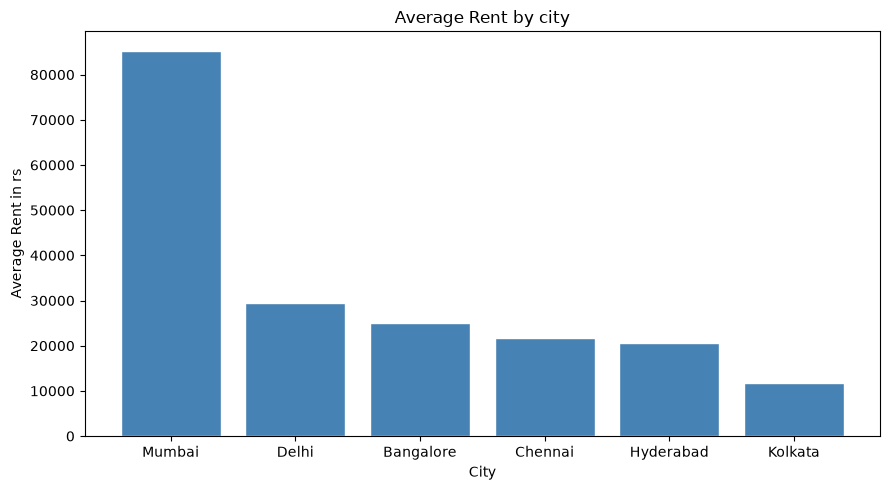

In [205]:
cities = city_stats.index.tolist()
avg_rents = city_stats["Mean"].tolist()

plt.figure(figsize=(9, 5))
plt.bar(cities, avg_rents, color="steelblue", edgecolor="white")
plt.title("Average Rent by city")
plt.xlabel("City")
plt.ylabel("Average Rent in rs")
plt.tight_layout()
plt.show()

Mumbai has by far the highest average rent among the six cities, at around Rs. 85,321. Kolkata has the lowest average at Rs. 11,645. The differences across cities are quite large, which shows that location is an important factor when looking at rental prices.

The standard deviation for Mumbai and Bangalore is very high, which means there is a wide range of rental prices within those cities too.

## Covariance and Correlation

We use size and Rent for covariance and correlation. Both are numerical variables, which is required for these calculations to make sense.

In [206]:
cov_size_rent = np.cov(df["Size"], df["Rent"], ddof=1)[0][1]
print("Covariance (Size, Rent):", round(cov_size_rent, 2))

Covariance (Size, Rent): 20485348.0


The covariance is positive (around 20,485,348). This tells us that Size and Rent move in the same direction: larger properties tend to have higher rents. However, the actual number is hard to interpret because covariance depends on the scale of both variables.

In [207]:
corr_size_rent = df["Size"].corr(df["Rent"])
print("Correlation (Size, Rent):", round(corr_size_rent, 4))

Correlation (Size, Rent): 0.4136


The correlation is 0.4136. This is a moderate positive correlation. It means there is a relationship between property size and rent, but it is not very strong. Many other factors (city, furnishing, floor, etc.) also affect rent.

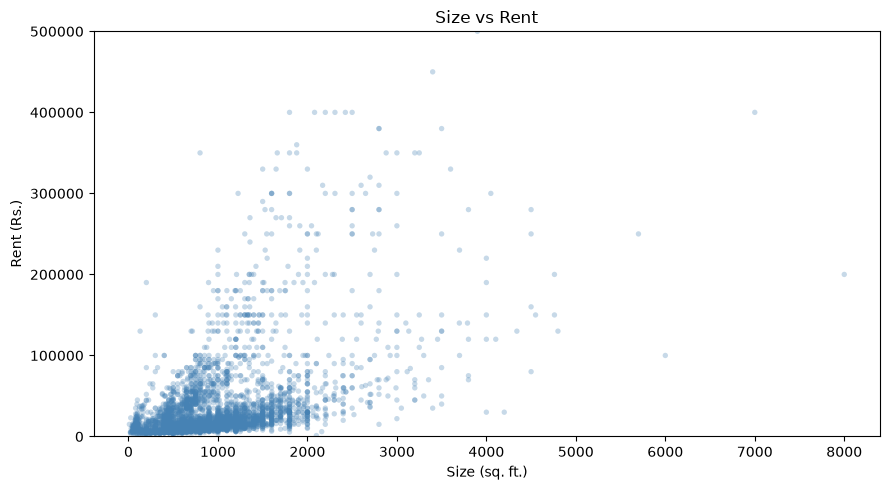

In [208]:
plt.figure(figsize=(9, 5))
plt.scatter(df["Size"], df["Rent"], alpha=0.3, color="steelblue", edgecolors="none", s=15)
plt.title("Size vs Rent")
plt.xlabel("Size (sq. ft.)")
plt.ylabel("Rent (Rs.)")
plt.ylim(0, 500000)
plt.tight_layout()
plt.show()

The scatter plot shows a general upward trend: larger properties tend to cost more. But there is also a lot of spread, meaning size alone does not fully explain rent. The correlation of 0.41 reflects this.

## Law of Large Numbers

The Law of Large Numbers states that as the number of observations in a random sample increases, the sample mean tends to get closer to the true mean of the distribution.

In [209]:
reference_mean = df["Rent"].mean()
print("Reference mean (complete dataset): Rs.", round(reference_mean, 2))
print("Total Rent observations:", len(df["Rent"]))

Reference mean (complete dataset): Rs. 34993.45
Total Rent observations: 4746


For this demonstration, the mean of the complete available dataset (Rs. 34,993.45) is treated as the reference mean. We will randomly sample different numbers of listings and track how the sample mean changes.

In [ ]:
random_state = 42 # fixed seed for same results when we re run the code
sample_sizes = [10, 25, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 4746]

sample_means = []
diffs = []

for n in sample_sizes:
    sample = df["Rent"].sample(n=n, random_state=random_state)
    sm = sample.mean()
    sample_means.append(round(sm, 2))
    diffs.append(round(sm - reference_mean, 2))

lln_table = pd.DataFrame({
    "Sample Size": sample_sizes,
    "Sample Mean (Rs.)": sample_means,
    "Diff from Reference Mean (Rs.)": diffs
})

print(lln_table.to_string(index=False))

 Sample Size  Sample Mean (Rs.)  Diff from Reference Mean (Rs.)
          10           60850.00                        25856.55
          25           50300.00                        15306.55
          50           46380.00                        11386.55
         100           41134.99                         6141.54
         250           33893.95                        -1099.50
         500           37549.68                         2556.23
        1000           34495.06                         -498.39
        2000           35995.49                         1002.03
        3000           35042.86                           49.41
        4000           35394.75                          401.30
        4746           34993.45                            0.00


For small samples (n=10, 25), the sample mean can be quite different from the reference mean. As the sample size increases, the sample mean gets closer and stays closer to Rs. 34,993. This is the Law of Large Numbers in action.

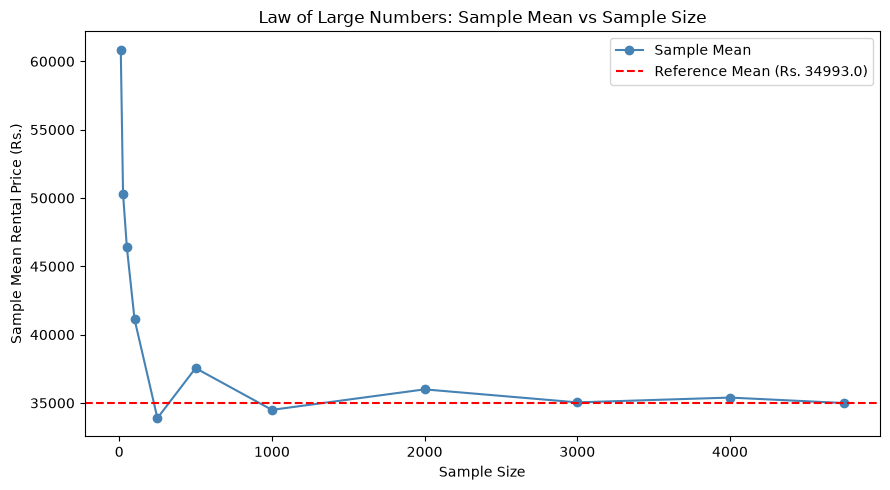

In [211]:
plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, sample_means, marker="o", color="steelblue", label="Sample Mean")
plt.axhline(y=reference_mean, color="red", linestyle="--",
            label="Reference Mean (Rs. " + str(round(reference_mean, 0)) + ")")
plt.title("Law of Large Numbers: Sample Mean vs Sample Size")
plt.xlabel("Sample Size")
plt.ylabel("Sample Mean Rental Price (Rs.)")
plt.legend()
plt.tight_layout()
plt.show()

The graph clearly shows that the sample mean starts far from the reference mean at small sample sizes and gradually converges toward it as the sample size increases. At n=4746 (the full dataset), the sample mean equals the reference mean exactly.

The sample mean does not always move strictly closer with every step since each sample is random. But the general trend of decreasing deviation is visible, which is consistent with the Law of Large Numbers.

We use random sampling instead of just taking the first n rows because random sampling gives each property an equal chance of being selected. Taking the first rows would not represent the full variety of the dataset.


## 10. Key Findings

Based on the actual calculated results from the dataset:

1. The dataset contains 4,746 rental property listings across 6 Indian cities, with 12 columns.
2. The mean rent is Rs. 34,993 and the median rent is Rs. 16,000. The gap indicates that a few high-rent listings pull the average upward.
3. Mumbai has the highest average rent (Rs. 85,321) among the six cities. Kolkata has the lowest (Rs. 11,645). Location clearly has a large effect on rental prices.
4. The standard deviation of rent is Rs. 78,106, which is very large compared to the mean, reflecting the wide spread of rental prices.
5. Size and Rent have a positive correlation of 0.4136. Larger properties tend to have higher rents, but the relationship is moderate.
6. As the sample size increased in the LLN experiment, the sample mean became more stable around the reference mean of Rs. 34,993, demonstrating the Law of Large Numbers with real rental price data.

## Conclusion

In this CP, we studied rental property data from 4,746 listings across 6 Indian cities. Using basic statistical measures, we found that rental prices are right-skewed with a mean significantly higher than the median, and that there is a lot of variation in prices. City is a strong factor in this variation, with Mumbai listings having an average rent more than seven times higher than Kolkata listings. Property size shows a moderate positive correlation (0.41) with rent.

The Law of Large Numbers was demonstrated using random samples of increasing size. The sample mean started far from the reference mean for small samples and steadily converged toward it as the sample size grew. This shows, using real rental data, why larger samples give more reliable estimates of the true average.